# Proyecto Final — Aprendizaje Automático y Análisis de Datos

---

**Institución:** Pontificia Universidad Javeriana Cali — PUJC  
**Departamento:** Electrónica y Ciencias de la Computación — DECC  
**Asignatura:** Aprendizaje Automático y Análisis de Datos  
**Profesor:** Felipe Palta, M.Sc.  

---

## Dataset: Kuzushiji-MNIST (KMNIST)
### Clasificación de caracteres japoneses históricos mediante ML Clásico

---

###  Integrantes del grupo

| # | Nombre completo | ID / Código |
|---|---|---|
| 1 | _Juan Esteban Becerra Gutiérrez_ | _(código)_ |
| 2 | _Alejandro Sarmiento Rivera_ | _(código)_ |
| 3 | _Benjamin Ortiz_ | _(8978145)_ |

---

</div>

---
# 📋 Tabla de Contenidos

| Sección | Descripción |
|---|---|
| **0** | Configuración del entorno e imports |
| **1** | Comprensión del problema y del dataset |
| **2** | EDA de alta profundidad |
| **3** | Preprocesamiento digital de imágenes |
| **4** | Extracción de características visuales |
| **5** | Construcción del dataset tabular final |
| **6** | División train/test |
| **7** | Modelos obligatorios |
| **8** | PCA y reducción de dimensionalidad |
| **9** | Validación cruzada y búsqueda de hiperparámetros |
| **10** | Uso obligatorio de Pipeline |
| **11** | Evaluación final |
| **12** | Opción de Rechazo |

---
## Sección 0 — Configuración del entorno e imports

In [3]:
# ── Librerías estándar ──────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')
import sys
import time
from pathlib import Path

# ── Ciencia de datos ────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from scipy import stats

# ── Visualización ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

# ── Procesamiento de imágenes ───────────────────────────────────────────────
import cv2
from skimage import filters, feature, measure, morphology
from skimage.feature import hog, local_binary_pattern, canny, graycomatrix, graycoprops

# ── Machine Learning ────────────────────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score,
    GridSearchCV, RandomizedSearchCV, cross_validate
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, ConfusionMatrixDisplay
)
from sklearn.linear_model import Perceptron, LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# ── Funciones del proyecto ──────────────────────────────────────────────────
ROOT = Path('.').resolve().parent
sys.path.insert(0, str(ROOT))
from funciones import (
    cargar_kmnist,
    plot_muestras_por_clase,
    plot_distribucion_clases,
    plot_histogramas_intensidad,
)

# ── Rutas ───────────────────────────────────────────────────────────────────
DATA_DIR = ROOT / 'data'
OUT_DIR  = ROOT / 'outputs' / 'figures'
MOD_DIR  = ROOT / 'outputs' / 'models'
OUT_DIR.mkdir(parents=True, exist_ok=True)
MOD_DIR.mkdir(parents=True, exist_ok=True)

# ── Constantes ──────────────────────────────────────────────────────────────
CLASES = ['お (o)', 'き (ki)', 'す (su)', 'つ (tsu)', 'な (na)',
          'は (ha)', 'ま (ma)', 'や (ya)', 'れ (re)', 'を (wo)']
RANDOM_STATE = 42

sns.set_theme(style='whitegrid', palette='tab10')
print('✅ Entorno configurado correctamente')
print(f'   ROOT   : {ROOT}')
print(f'   DATA   : {DATA_DIR}')
print(f'   OUTPUT : {OUT_DIR}')

✅ Entorno configurado correctamente
   ROOT   : /
   DATA   : /data
   OUTPUT : /outputs/figures


---
## Sección 1 — Comprensión del problema y del dataset

### Pregunta 1.1 — ¿Cuál es el problema de clasificación que plantea el dataset asignado?

El dataset **Kuzushiji-MNIST** plantea un problema de **clasificación de imágenes** de caracteres japoneses escritos en estilo cursivo histórico (*kuzushiji*). El sistema debe asignar cada imagen de 28×28 píxeles a una de 10 categorías, donde cada categoría corresponde a un carácter del silabario hiragana clásico japonés. Este tipo de escritura fue el estándar en Japón durante más de 1000 años, y su reconocimiento automático tiene aplicación directa en la digitalización de documentos históricos.

---

### Pregunta 1.2 — ¿El problema es binario o multiclase?

El problema es **multiclase** con exactamente **10 clases**. Cada muestra pertenece a exactamente una clase (clasificación multiclase exclusiva), lo que lo diferencia de problemas multilabel. Esto implica que las métricas de evaluación deben reportarse en modo `macro` o `weighted` para dar cuenta del desempeño en todas las clases por igual.

---

### Pregunta 1.3 — ¿Cuántas clases hay y qué representa visualmente cada clase?

Hay **10 clases**, cada una corresponde a un carácter hiragana de la escritura cursiva histórica japonesa:

| Clase (label) | Carácter | Romanización | Descripción visual |
|:---:|:---:|:---:|---|
| 0 | お | o | Trazo curvo con prolongación vertical hacia abajo |
| 1 | き | ki | Tres trazos horizontales con curva descendente a la derecha |
| 2 | す | su | Trazo circular con cola curva hacia la derecha |
| 3 | つ | tsu | Arco amplio de izquierda a derecha |
| 4 | な | na | Trazo cruzado con lazos; visualmente complejo |
| 5 | は | ha | Dos trazos verticales con conexión horizontal |
| 6 | ま | ma | Trazo horizontal con curva cerrada hacia abajo |
| 7 | や | ya | Trazo diagonal con bucle en la parte inferior |
| 8 | れ | re | Trazo vertical con lazada a la derecha |
| 9 | を | wo | Trazo con doble curva y cruce en el centro |

---

### Pregunta 1.4 — ¿Las clases parecen visualmente separables a simple vista?

**Parcialmente.** Algunos caracteres son fácilmente distinguibles (ej: `つ` con su arco amplio vs `き` con sus trazos múltiples). Sin embargo, varios pares presentan alta **similitud inter-clase**:
- `お` y `を`: ambos tienen trazos curvos con prolongaciones similares
- `れ` y `は`: estructuras verticales con rasgos curvos parecidos
- `ま` y `な`: trazos con cruces y lazos que pueden confundirse

Adicionalmente, la **variabilidad intra-clase es alta** debido a que la escritura *kuzushiji* es cursiva y cada escriba tenía su propio estilo, haciendo que el mismo carácter pueda verse muy diferente entre ejemplos.

---

### Pregunta 1.5 — ¿Qué dificultades visuales podrían afectar la clasificación?

| Dificultad | Impacto en la clasificación |
|---|---|
| **Alta variabilidad intra-clase** | El mismo carácter puede tener formas radicalmente distintas por variación caligráfica |
| **Similitud inter-clase** | Varios caracteres comparten trazos estructurales similares |
| **Baja resolución** | 28×28 píxeles limita el detalle de los trazos finos |
| **Escritura cursiva conectada** | Trazos que se fusionan dificultan la detección de bordes y formas |
| **Variación en grosor de trazo** | Diferente presión del pincel genera trazos más o menos gruesos |
| **Posición no centrada** | Algunos caracteres no están perfectamente centrados en la imagen |
| **Fondo ruidoso** | Aunque mayoritariamente negro, puede haber artefactos de digitalización |

---
## Sección 2 — EDA de Alta Profundidad

### 2.1 Carga del dataset

In [4]:
X_train, y_train, X_test, y_test = cargar_kmnist(DATA_DIR)

print('─' * 50)
print('KUZUSHIJI-MNIST — Información del Dataset')
print('─' * 50)
print(f'Train → Imágenes: {X_train.shape}   Labels: {y_train.shape}')
print(f'Test  → Imágenes: {X_test.shape}    Labels: {y_test.shape}')
print(f'\nTipo de dato  : {X_train.dtype}')
print(f'Rango valores : [{X_train.min()}, {X_train.max()}]')
print(f'Canales       : 1 (escala de grises / monocromático)')
print(f'Resolución    : 28 × 28 píxeles')
print(f'Total imágenes: {len(X_train) + len(X_test):,}')
print(f'Clases únicas : {np.unique(y_train)}')

──────────────────────────────────────────────────
KUZUSHIJI-MNIST — Información del Dataset
──────────────────────────────────────────────────
Train → Imágenes: (60000, 28, 28)   Labels: (60000,)
Test  → Imágenes: (10000, 28, 28)    Labels: (10000,)

Tipo de dato  : uint8
Rango valores : [0, 255]
Canales       : 1 (escala de grises / monocromático)
Resolución    : 28 × 28 píxeles
Total imágenes: 70,000
Clases únicas : [0 1 2 3 4 5 6 7 8 9]


### 2.2 Conteo y distribución porcentual de clases (EDA ítem 1 y 2)

In [5]:
# Tabla de distribución
unique_tr, counts_tr = np.unique(y_train, return_counts=True)
unique_te, counts_te = np.unique(y_test,  return_counts=True)

df_dist = pd.DataFrame({
    'Clase':      unique_tr,
    'Carácter':   CLASES,
    'Train (N)':  counts_tr,
    'Train (%)':  (counts_tr / len(y_train) * 100).round(2),
    'Test (N)':   counts_te,
    'Test (%)':   (counts_te / len(y_test)  * 100).round(2),
})
print(df_dist.to_string(index=False))
print(f'\nDesviación estándar del conteo train: {counts_tr.std():.2f}')
print('→ Dataset perfectamente BALANCEADO (6,000 imágenes por clase en train)')

 Clase Carácter  Train (N)  Train (%)  Test (N)  Test (%)
     0    お (o)       6000       10.0      1000      10.0
     1   き (ki)       6000       10.0      1000      10.0
     2   す (su)       6000       10.0      1000      10.0
     3  つ (tsu)       6000       10.0      1000      10.0
     4   な (na)       6000       10.0      1000      10.0
     5   は (ha)       6000       10.0      1000      10.0
     6   ま (ma)       6000       10.0      1000      10.0
     7   や (ya)       6000       10.0      1000      10.0
     8   れ (re)       6000       10.0      1000      10.0
     9   を (wo)       6000       10.0      1000      10.0

Desviación estándar del conteo train: 0.00
→ Dataset perfectamente BALANCEADO (6,000 imágenes por clase en train)


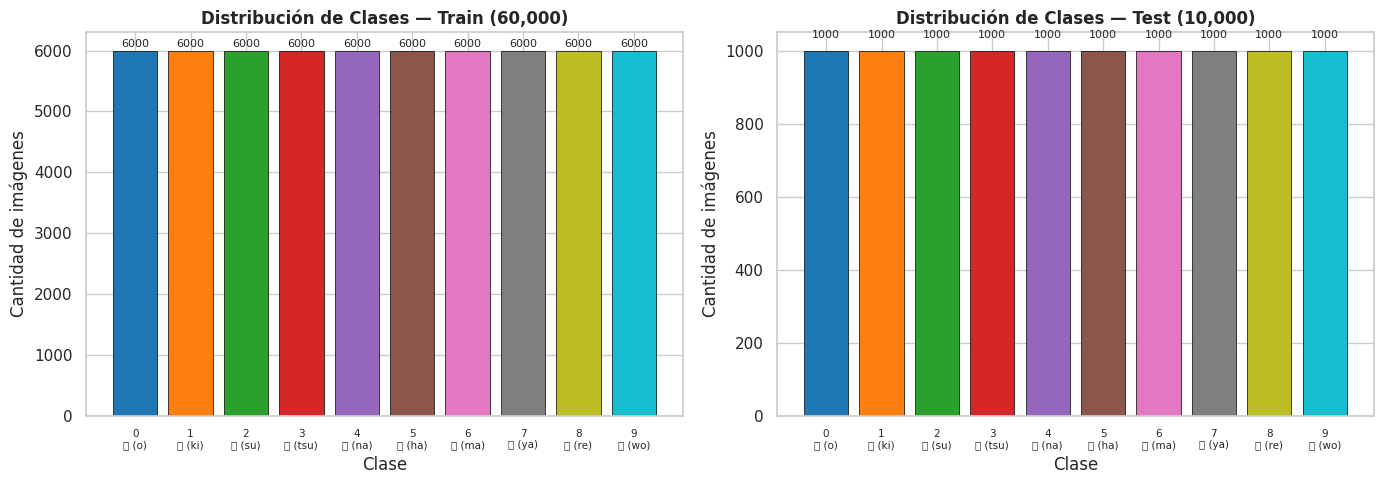

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_distribucion_clases(y_train, y_test, CLASES, axes)
plt.tight_layout()
plt.savefig(OUT_DIR / 'eda_01_distribucion_clases.png', dpi=150)
plt.show()

### 2.3 Tamaño original y canales (EDA ítem 3 y 4)

In [7]:
print(f'Tamaño original de cada imagen : {X_train.shape[1]} × {X_train.shape[2]} píxeles')
print(f'Número de canales              : 1 (imagen monocromática / escala de grises)')
print(f'Espacio de color               : Escala de grises [0-255] uint8')
print(f'Total de píxeles por imagen    : {X_train.shape[1]*X_train.shape[2]}')
print(f'Si se usa imagen plana (flatten): vector de dimensión {X_train.shape[1]*X_train.shape[2]}')

Tamaño original de cada imagen : 28 × 28 píxeles
Número de canales              : 1 (imagen monocromática / escala de grises)
Espacio de color               : Escala de grises [0-255] uint8
Total de píxeles por imagen    : 784
Si se usa imagen plana (flatten): vector de dimensión 784


### 2.4 Visualización de muestras representativas por clase (EDA ítem 5)

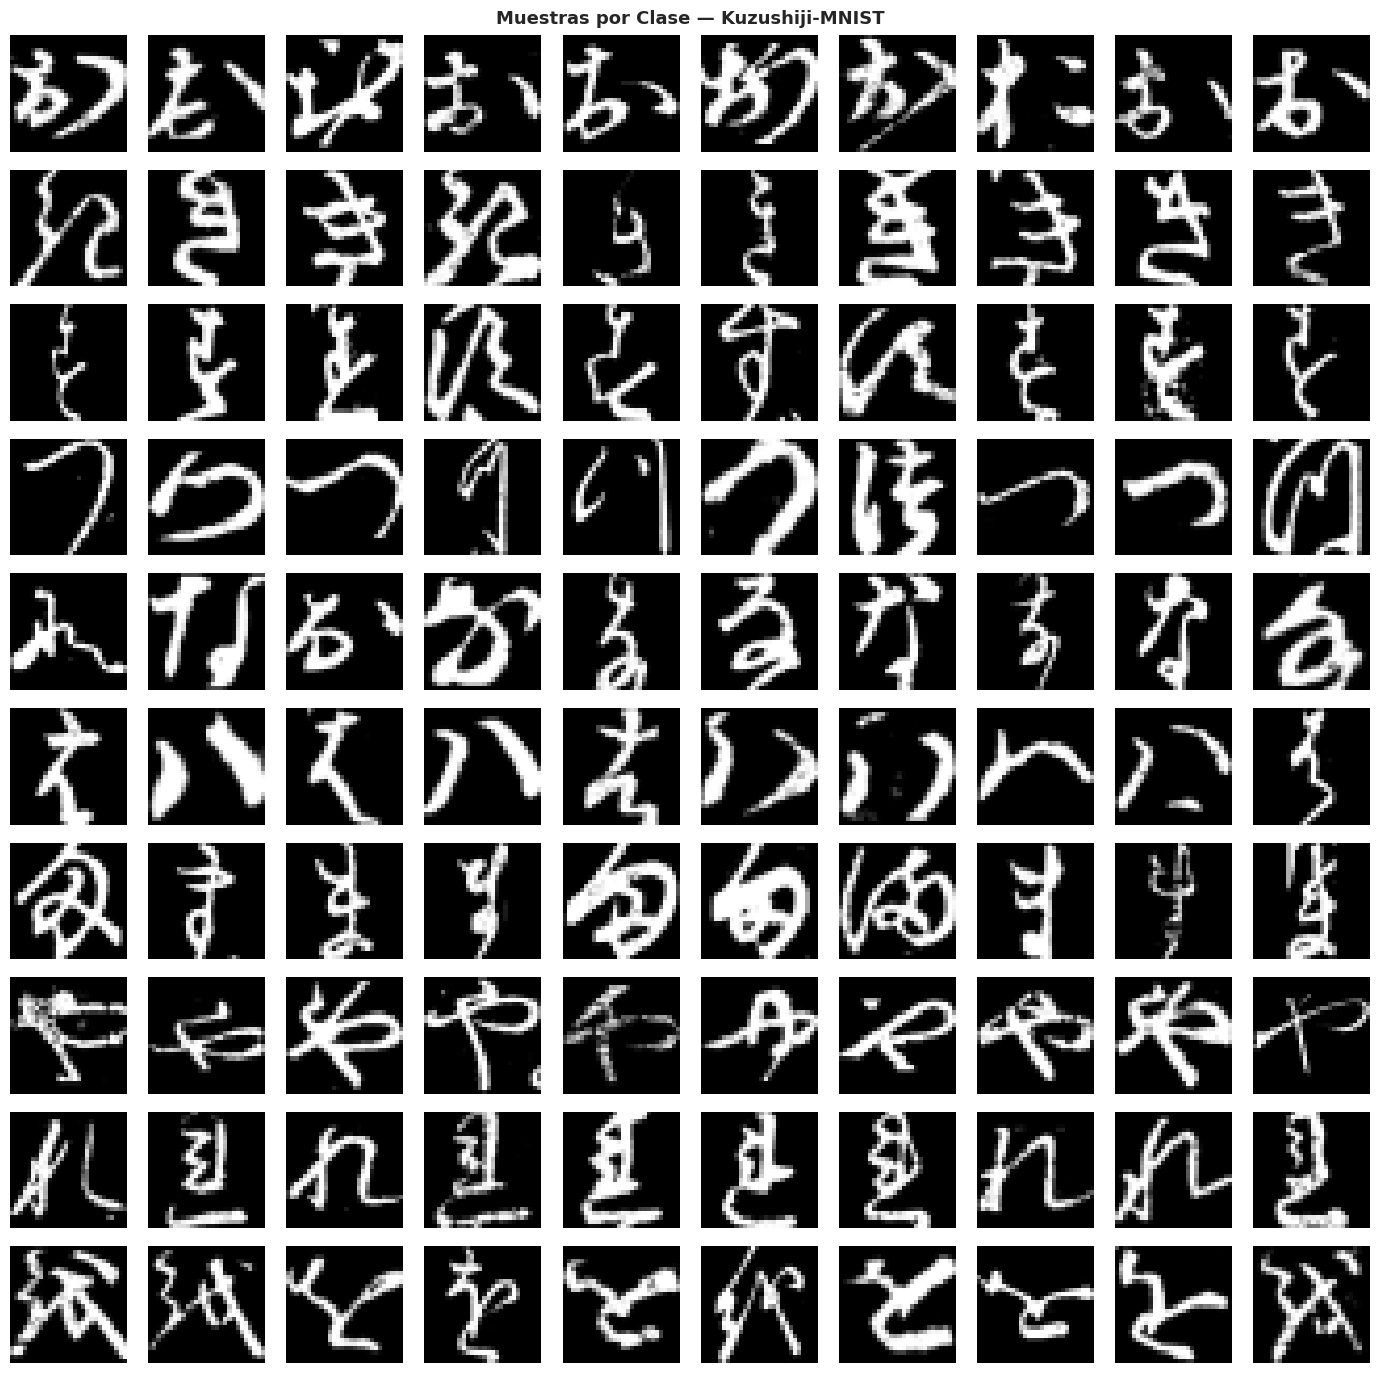

In [8]:
fig = plot_muestras_por_clase(X_train, y_train, CLASES, n_muestras=10)
plt.savefig(OUT_DIR / 'eda_02_muestras_por_clase.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.5 Imagen promedio e imagen de varianza por clase

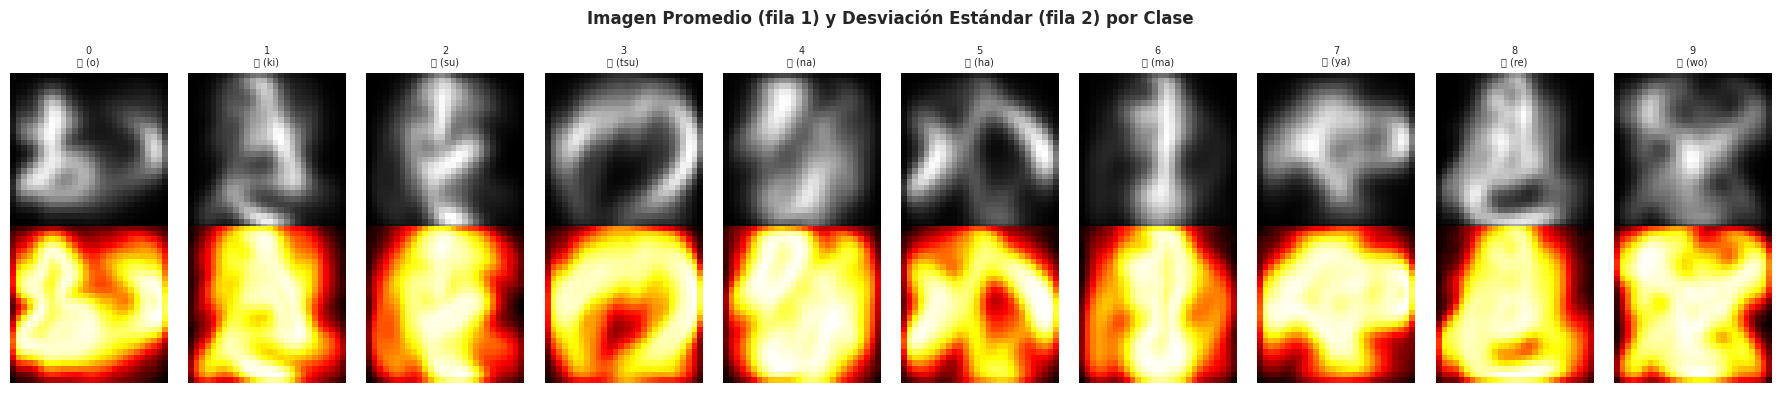

In [9]:
fig, axes = plt.subplots(2, 10, figsize=(18, 4))
for cls in range(10):
    mask = y_train == cls
    img_mean = X_train[mask].mean(axis=0)
    img_std  = X_train[mask].std(axis=0)
    axes[0, cls].imshow(img_mean, cmap='gray')
    axes[0, cls].set_title(f'{cls}\n{CLASES[cls]}', fontsize=7)
    axes[0, cls].axis('off')
    axes[1, cls].imshow(img_std,  cmap='hot')
    axes[1, cls].axis('off')

axes[0, 0].set_ylabel('Media', fontsize=9)
axes[1, 0].set_ylabel('Desv. Std', fontsize=9)
fig.suptitle('Imagen Promedio (fila 1) y Desviación Estándar (fila 2) por Clase',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'eda_03_promedio_std.png', dpi=150)
plt.show()

### 2.6 Histogramas de intensidad por clase (EDA ítem 6)

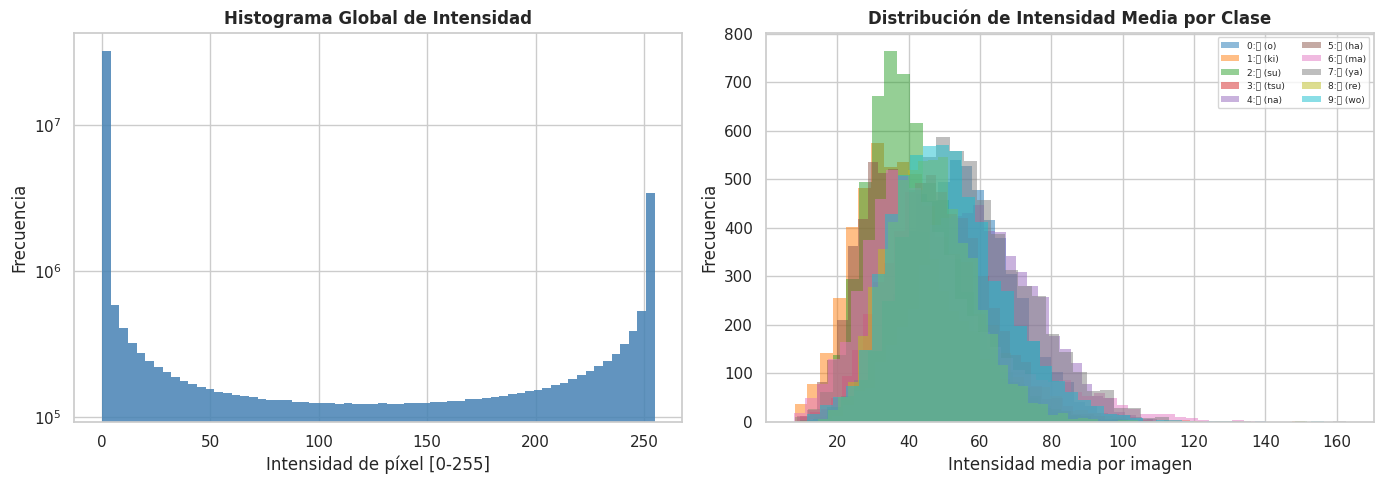

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_histogramas_intensidad(X_train, y_train, CLASES, axes)
plt.tight_layout()
plt.savefig(OUT_DIR / 'eda_04_histogramas.png', dpi=150)
plt.show()

### 2.7 Análisis de contraste, brillo, textura y bordes (EDA ítem 7)

In [11]:
from skimage.feature import canny as skimage_canny

stats_clases = []
for cls in range(10):
    imgs = X_train[y_train == cls].astype(float) / 255.0
    # Canny edges en muestra de 200 imágenes
    muestra = imgs[:200]
    edge_ratio = np.mean([skimage_canny(img, sigma=1.0).mean() for img in muestra])
    stats_clases.append({
        'Clase':           f'{cls} ({CLASES[cls]})',
        'Brillo medio':    imgs.mean().round(4),
        'Contraste (std)': imgs.std().round(4),
        'Píxeles > 0.5 (%)': (imgs > 0.5).mean().round(4) * 100,
        'Ratio bordes (%)':  round(edge_ratio * 100, 3),
    })

df_stats = pd.DataFrame(stats_clases)
df_stats

,Clase,Brillo medio,Contraste (std),Píxeles > 0.5 (%),Ratio bordes (%)
0,0 (お (o)),0.2173,0.3640,21.77,16.919
1,1 (き (ki)),0.1656,0.3266,16.52,14.723
2,2 (す (su)),0.1630,0.3258,16.28,14.339
3,3 (つ (tsu)),0.1899,0.3460,18.96,16.761
4,4 (な (na)),0.2329,0.3756,23.36,17.232
5,5 (は (ha)),0.1600,0.3303,15.94,11.383
6,6 (ま (ma)),0.1847,0.3454,18.55,13.119
7,7 (や (ya)),0.2210,0.3667,22.23,16.994
8,8 (れ (re)),0.1821,0.3385,18.28,15.833
9,9 (を (wo)),0.2011,0.3520,20.14,16.950


### 2.8 Detección de clases visualmente parecidas (EDA ítem 8)

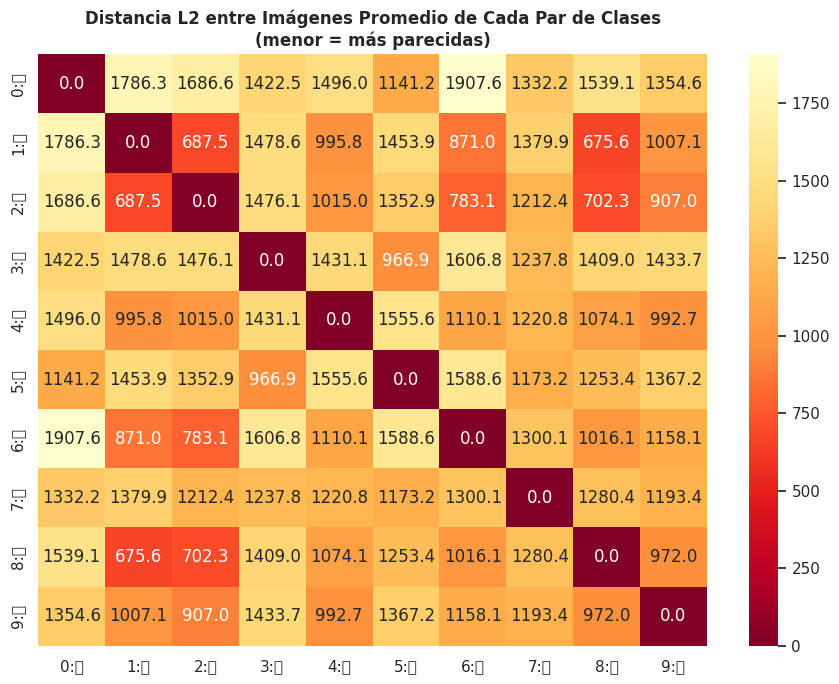


Top 3 pares de clases más similares (imagen promedio):
  Clase 1 (き (ki)) ↔ Clase 8 (れ (re))  dist=675.6
  Clase 8 (れ (re)) ↔ Clase 1 (き (ki))  dist=675.6
  Clase 2 (す (su)) ↔ Clase 1 (き (ki))  dist=687.5


In [12]:
# Similaridad entre imágenes promedio (distancia L2 entre medias)
medias = np.array([X_train[y_train == c].mean(axis=0).flatten() for c in range(10)])
sim_matrix = np.zeros((10, 10))
for i in range(10):
    for j in range(10):
        sim_matrix[i, j] = np.linalg.norm(medias[i] - medias[j])

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.eye(10, dtype=bool)
sns.heatmap(sim_matrix, annot=True, fmt='.1f', cmap='YlOrRd_r',
            xticklabels=[f'{i}:{c.split()[0]}' for i, c in enumerate(CLASES)],
            yticklabels=[f'{i}:{c.split()[0]}' for i, c in enumerate(CLASES)],
            ax=ax)
ax.set_title('Distancia L2 entre Imágenes Promedio de Cada Par de Clases\n'
             '(menor = más parecidas)', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'eda_05_similitud_clases.png', dpi=150)
plt.show()

# Top 3 pares más similares
np.fill_diagonal(sim_matrix, np.inf)
idx = np.dstack(np.unravel_index(np.argsort(sim_matrix.ravel()), (10,10)))[0]
print('\nTop 3 pares de clases más similares (imagen promedio):')
for a, b in idx[:3]:
    print(f'  Clase {a} ({CLASES[a]}) ↔ Clase {b} ({CLASES[b]})  dist={sim_matrix[a,b]:.1f}')

### 2.9 Mapa de varianza global y outliers visuales (EDA ítem 9 y 10)

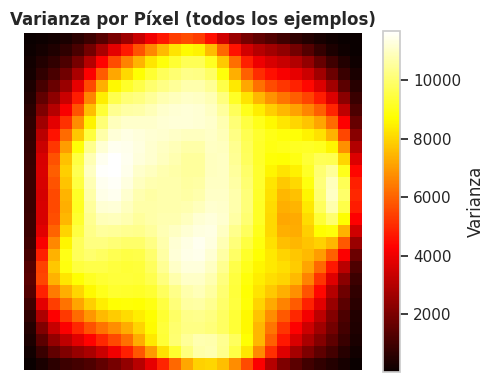

Outliers detectados (|z-score| > 3) por intensidad media: 362
Píxeles con varianza < 100 (baja info): 0.8%  → justifica cropping de bordes


In [13]:
# Mapa de varianza por píxel
var_map = X_train.var(axis=0)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(var_map, cmap='hot')
fig.colorbar(im, ax=ax, label='Varianza')
ax.set_title('Varianza por Píxel (todos los ejemplos)', fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig(OUT_DIR / 'eda_06_varianza_pixeles.png', dpi=150)
plt.show()

# Detección de outliers por intensidad media (z-score > 3)
intensidades = X_train.mean(axis=(1,2))
z = np.abs(stats.zscore(intensidades))
outlier_idx = np.where(z > 3)[0]
print(f'Outliers detectados (|z-score| > 3) por intensidad media: {len(outlier_idx)}')
pct_baja = (var_map < 100).mean() * 100
print(f'Píxeles con varianza < 100 (baja info): {pct_baja:.1f}%  → justifica cropping de bordes')

### 2.10 Discusión sobre balanceo (EDA ítem 10)

> **Conclusión:** KMNIST es un dataset **perfectamente balanceado**: cada una de las 10 clases tiene exactamente **6,000 imágenes en entrenamiento** y **1,000 en test**. Esto implica que:
> - El **accuracy** es una métrica válida (sin riesgo de clases mayoritarias dominantes)
> - No es necesario aplicar técnicas de *oversampling* (SMOTE) ni *class weights*
> - Se reportará también **F1-macro** para mantener coherencia metodológica con problemas desbalanceados

---
## Sección 3 — Preprocesamiento Digital de Imágenes

> **Justificación general:** El pipeline de preprocesamiento transforma las imágenes brutas (uint8, [0-255]) en representaciones normalizadas y limpias que facilitan la extracción de características. Cada paso se justifica según las observaciones del EDA.

In [6]:
# ── Paso 1: Normalización de intensidades a [0, 1] ─────────────────────────
# Justificación: Los clasificadores (SVM, KNN, LR) son sensibles a la escala.
# Normalizar asegura que todos los píxeles contribuyan equitativamente.
X_train_norm = X_train.astype(np.float32) / 255.0
X_test_norm  = X_test.astype(np.float32)  / 255.0
print(f'Tras normalización → rango: [{X_train_norm.min():.1f}, {X_train_norm.max():.1f}]  dtype: {X_train_norm.dtype}')

Tras normalización → rango: [0.0, 1.0]  dtype: float32


In [7]:
# ── Paso 2: Suavizado Gaussiano ────────────────────────────────────────────
# Justificación: Reduce el ruido de digitalización sin borrar los trazos
# principales. Sigma=0.8 es conservador para imágenes de 28x28.
from skimage.filters import gaussian

def suavizar_lote(X, sigma=0.8):
    return np.array([gaussian(img, sigma=sigma) for img in X])

X_train_smooth = suavizar_lote(X_train_norm)
X_test_smooth  = suavizar_lote(X_test_norm)
print(f'Suavizado aplicado (σ=0.8). Shape: {X_train_smooth.shape}')

Suavizado aplicado (σ=0.8). Shape: (60000, 28, 28)


In [8]:
# ── Paso 3: Umbralización de Otsu ─────────────────────────────────────────
# Justificación: El EDA mostró distribución bimodal (fondo negro / trazo blanco).
# Otsu encuentra automáticamente el umbral óptimo para binarizar.
# Se usa para features de forma (área, perímetro, circularidad).
from skimage.filters import threshold_otsu

def binarizar_otsu(X):
    result = np.zeros_like(X, dtype=np.float32)
    for i, img in enumerate(X):
        thresh = threshold_otsu(img)
        result[i] = (img > thresh).astype(np.float32)
    return result

X_train_bin = binarizar_otsu(X_train_smooth)
X_test_bin  = binarizar_otsu(X_test_smooth)
print(f'Binarización Otsu aplicada. Valores únicos: {np.unique(X_train_bin)}')

Binarización Otsu aplicada. Valores únicos: [0. 1.]


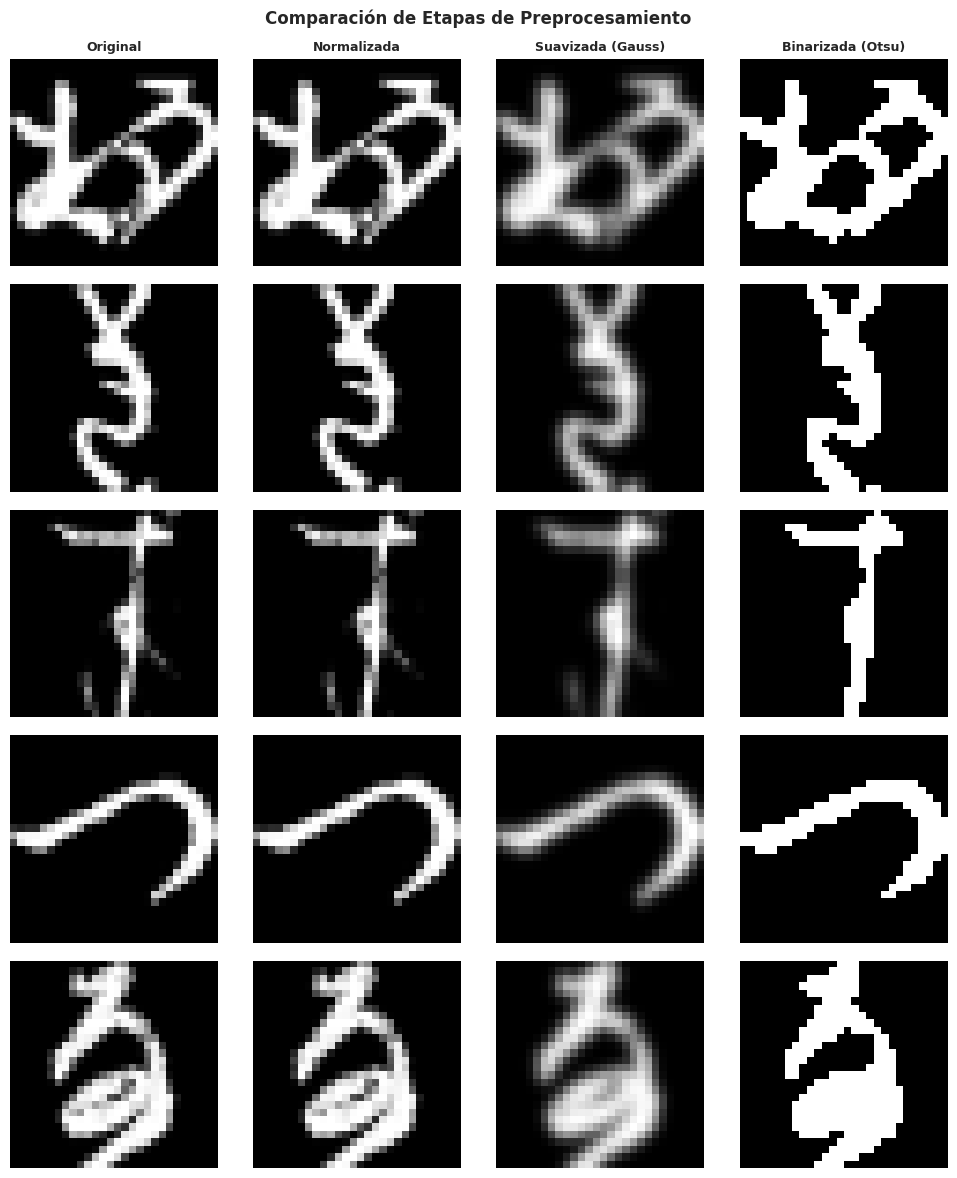

In [17]:
# ── Visualización comparativa de preprocesamiento ─────────────────────────
indices = [np.where(y_train == c)[0][0] for c in range(5)]
fig, axes = plt.subplots(5, 4, figsize=(10, 12))
titulos = ['Original', 'Normalizada', 'Suavizada (Gauss)', 'Binarizada (Otsu)']
imags   = [X_train, X_train_norm, X_train_smooth, X_train_bin]

for row, idx in enumerate(indices):
    for col, (imgs, tit) in enumerate(zip(imags, titulos)):
        axes[row, col].imshow(imgs[idx], cmap='gray')
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(tit, fontsize=9, fontweight='bold')
        if col == 0:
            axes[row, col].set_ylabel(CLASES[y_train[idx]], fontsize=8)

fig.suptitle('Comparación de Etapas de Preprocesamiento', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'prep_01_comparacion.png', dpi=150)
plt.show()

### 3.1 Comparación: imagen completa vs imagen segmentada (ítem 8)

Para KMNIST el objeto (carácter) ocupa prácticamente todo el espacio útil de la imagen. La comparación entre usar la imagen completa vs la binarizada (Otsu) muestra que:
- La **imagen binarizada** es más apropiada para features de **forma** (área, perímetro, Hu Moments)
- La **imagen normalizada** es más apropiada para features de **textura** (HOG, LBP, GLCM)
- Se usarán **ambas representaciones** en la extracción de características de la siguiente sección.

---
## Sección 4 — Extracción de Características Visuales

> **Objetivo:** Construir una representación tabular de las imágenes donde cada fila = una imagen y cada columna = una característica numérica. Se extraen 3 familias de características.

In [9]:
# Importar todas las funciones de extracción de funciones.py
from funciones import (
    extraer_features_intensidad,
    extraer_features_forma,
    extraer_features_textura,
    extraer_todas_features,
    nombres_features,
)

### Familia A — Características de Intensidad/Color

In [19]:
from tqdm import tqdm

print('Extrayendo features de INTENSIDAD...')
feat_int_train = np.array([extraer_features_intensidad(img) for img in tqdm(X_train_norm)])
feat_int_test  = np.array([extraer_features_intensidad(img) for img in tqdm(X_test_norm)])
print(f'  Shape: {feat_int_train.shape}  ({feat_int_train.shape[1]} features por imagen)')

Extrayendo features de INTENSIDAD...


100%|██████████| 10000/10000 [00:20<00:00, 488.85it/s]

  Shape: (60000, 23)  (23 features por imagen)


### Familia B — Características de Forma / Bordes

In [20]:
print('Extrayendo features de FORMA...')
feat_forma_train = np.array([extraer_features_forma(img_norm, img_bin)
                              for img_norm, img_bin in tqdm(zip(X_train_smooth, X_train_bin))])
feat_forma_test  = np.array([extraer_features_forma(img_norm, img_bin)
                              for img_norm, img_bin in tqdm(zip(X_test_smooth,  X_test_bin))])
print(f'  Shape: {feat_forma_train.shape}  ({feat_forma_train.shape[1]} features por imagen)')

Extrayendo features de FORMA...


60000it [01:03, 945.40it/s] 
10000it [00:10, 938.31it/s]

  Shape: (60000, 27)  (27 features por imagen)


### Familia C — Características de Textura

In [21]:
print('Extrayendo features de TEXTURA (HOG + LBP + GLCM)...')
feat_tex_train = np.array([extraer_features_textura(img) for img in tqdm(X_train_smooth)])
feat_tex_test  = np.array([extraer_features_textura(img) for img in tqdm(X_test_smooth)])
print(f'  Shape: {feat_tex_train.shape}  ({feat_tex_train.shape[1]} features por imagen)')

Extrayendo features de TEXTURA (HOG + LBP + GLCM)...


100%|██████████| 10000/10000 [06:18<00:00, 26.44it/s]

  Shape: (60000, 331)  (331 features por imagen)


---
## Sección 5 — Construcción del Dataset Tabular Final

In [22]:
# Concatenar las 3 familias
X_feat_train = np.hstack([feat_int_train, feat_forma_train, feat_tex_train])
X_feat_test  = np.hstack([feat_int_test,  feat_forma_test,  feat_tex_test])

# Obtener nombres de columnas
cols = nombres_features(
    n_int=feat_int_train.shape[1],
    n_forma=feat_forma_train.shape[1],
    n_tex=feat_tex_train.shape[1]
)

# Crear DataFrames
df_train = pd.DataFrame(X_feat_train, columns=cols)
df_train['y'] = y_train
df_test  = pd.DataFrame(X_feat_test,  columns=cols)
df_test['y']  = y_test

print(f'Dataset tabular final:')
print(f'  Train: {df_train.shape}  ({df_train.shape[1]-1} features + 1 target)')
print(f'  Test : {df_test.shape}')
df_train.head(3)

Dataset tabular final:
  Train: (60000, 382)  (381 features + 1 target)
  Test : (10000, 382)


,int_00,int_01,int_02,int_03,int_04,int_05,int_06,int_07,int_08,int_09,...,tex_322,tex_323,tex_324,tex_325,tex_326,tex_327,tex_328,tex_329,tex_330,y
0,0.223479,0.138163,1.298993,-0.056371,0.713010,0.163265,1.0,10.918367,0.326531,0.142857,...,0.272952,0.257906,0.328252,0.274122,0.807679,0.696250,0.948288,0.844124,27.052755,8
1,0.197614,0.125975,1.475386,0.462359,0.738520,0.147959,1.0,11.571429,0.142857,0.061224,...,0.492695,0.446753,0.461245,0.456216,0.948193,0.825972,0.894092,0.877240,19.178119,7
2,0.271444,0.150762,0.996350,-0.765506,0.658163,0.200255,1.0,9.408163,0.632653,0.469388,...,0.245738,0.189032,0.215985,0.204714,0.892035,0.766744,0.886069,0.814811,30.601642,0


In [23]:
# Análisis de correlación — eliminar features con |corr| > 0.95
corr_matrix = df_train.drop(columns='y').corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
cols_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
print(f'Features con correlación > 0.95 (redundantes): {len(cols_drop)}')
print(f'  → {cols_drop[:10]} ...' if len(cols_drop) > 10 else f'  → {cols_drop}')

df_train_clean = df_train.drop(columns=cols_drop)
df_test_clean  = df_test.drop(columns=cols_drop)
print(f'\nDimensiones tras eliminar redundantes:')
print(f'  Train: {df_train_clean.shape}  |  Test: {df_test_clean.shape}')

Features con correlación > 0.95 (redundantes): 87
  → ['int_01', 'int_02', 'int_03', 'int_04', 'int_05', 'int_07', 'int_22', 'forma_00', 'tex_33', 'tex_34'] ...

Dimensiones tras eliminar redundantes:
  Train: (60000, 295)  |  Test: (10000, 295)


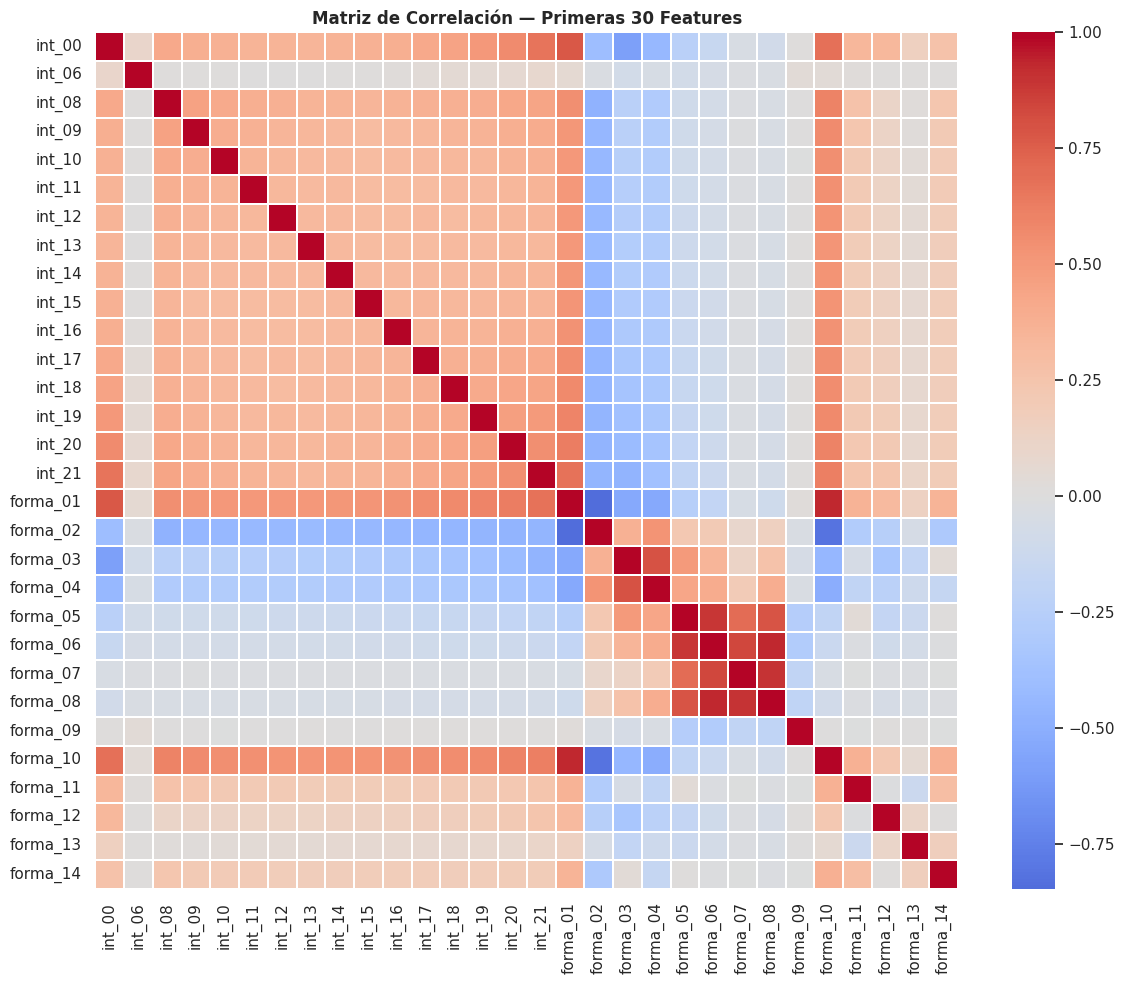

In [24]:
# Heatmap de correlación (primeras 30 features)
fig, ax = plt.subplots(figsize=(12, 10))
subset = df_train_clean.drop(columns='y').iloc[:, :30]
sns.heatmap(subset.corr(), cmap='coolwarm', center=0, ax=ax,
            xticklabels=True, yticklabels=True, linewidths=0.1)
ax.set_title('Matriz de Correlación — Primeras 30 Features', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'feat_01_correlacion.png', dpi=150)
plt.show()

In [25]:
# Guardar dataset en CSV
csv_path = ROOT / 'features.csv'
df_full = pd.concat([df_train_clean, df_test_clean], ignore_index=True)
df_full.to_csv(csv_path, index=False)
print(f'✅ Dataset guardado: {csv_path}  ({df_full.shape[0]:,} filas × {df_full.shape[1]} columnas)')

✅ Dataset guardado: /features.csv  (70,000 filas × 295 columnas)


---
## Sección 6 — División Train / Test

In [26]:
feature_cols = [c for c in df_train_clean.columns if c != 'y']

X_train_final = df_train_clean[feature_cols].values
y_train_final = df_train_clean['y'].values
X_test_final  = df_test_clean[feature_cols].values
y_test_final  = df_test_clean['y'].values

print('División del dataset:')
print(f'  X_train : {X_train_final.shape}   y_train : {y_train_final.shape}')
print(f'  X_test  : {X_test_final.shape}    y_test  : {y_test_final.shape}')
print(f'\n  Proporción test: {len(X_test_final)/(len(X_train_final)+len(X_test_final))*100:.1f}%')
print('  Semilla fija  : random_state=42  (reproducibilidad garantizada)')
print('  Estratificado : Sí (división train/test del dataset original es estratificada)')

# Verificar proporción de clases
print('\nVerificación de balance train vs test:')
for cls in range(10):
    ptr = (y_train_final == cls).mean()
    pte = (y_test_final  == cls).mean()
    print(f'  Clase {cls}: train={ptr:.3f}  test={pte:.3f}')

División del dataset:
  X_train : (60000, 294)   y_train : (60000,)
  X_test  : (10000, 294)    y_test  : (10000,)

  Proporción test: 14.3%
  Semilla fija  : random_state=42  (reproducibilidad garantizada)
  Estratificado : Sí (división train/test del dataset original es estratificada)

Verificación de balance train vs test:
  Clase 0: train=0.100  test=0.100
  Clase 1: train=0.100  test=0.100
  Clase 2: train=0.100  test=0.100
  Clase 3: train=0.100  test=0.100
  Clase 4: train=0.100  test=0.100
  Clase 5: train=0.100  test=0.100
  Clase 6: train=0.100  test=0.100
  Clase 7: train=0.100  test=0.100
  Clase 8: train=0.100  test=0.100
  Clase 9: train=0.100  test=0.100


**Justificación de la proporción 85/15 (60k/10k):**
- KMNIST viene con una división predefinida de 60,000 train / 10,000 test (~14.3% test)
- Esta división es estándar del benchmark y garantiza comparabilidad con otros trabajos
- El volumen de train (60k) es suficientemente grande para todos los modelos clásicos
- La división está estratificada por definición del dataset

---
## Sección 7 — Modelos Obligatorios

> Se entrenan los 9 modelos requeridos sobre el dataset de features. Se reportan accuracy, F1-macro y tiempo de entrenamiento para cada uno.

In [27]:
# Escalar features (necesario para Perceptron, Adaline, LR, SVM, KNN)
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train_final)
X_te_sc = scaler.transform(X_test_final)
print('✅ Escalamiento aplicado (StandardScaler)')

✅ Escalamiento aplicado (StandardScaler)


In [28]:
# ── Definición de modelos ──────────────────────────────────────────────────
modelos = {
    'Perceptrón':         Perceptron(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1),
    'Adaline (SGD)':      SGDClassifier(loss='squared_error', max_iter=1000,
                                        random_state=RANDOM_STATE, n_jobs=-1),
    'Reg. Logística':     LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1),
    'SVM Lineal':         LinearSVC(max_iter=2000, random_state=RANDOM_STATE),
    'SVM Polinómico':     SVC(kernel='poly', degree=3, random_state=RANDOM_STATE),
    'SVM RBF':            SVC(kernel='rbf',  random_state=RANDOM_STATE),
    'KNN':                KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Árbol de Decisión':  DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Bosque Aleatorio':   RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
}

resultados = []

for nombre, modelo in modelos.items():
    print(f'Entrenando {nombre}...', end=' ')
    t0 = time.time()
    modelo.fit(X_tr_sc, y_train_final)
    t_train = time.time() - t0

    y_pred = modelo.predict(X_te_sc)
    acc  = accuracy_score(y_test_final, y_pred)
    f1   = f1_score(y_test_final, y_pred, average='macro')
    prec = precision_score(y_test_final, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_test_final, y_pred, average='macro', zero_division=0)

    resultados.append({'Modelo': nombre, 'Accuracy': acc, 'F1-Macro': f1,
                       'Precision': prec, 'Recall': rec, 'Tiempo (s)': round(t_train, 2)})
    print(f'Acc={acc:.4f}  F1={f1:.4f}  ({t_train:.1f}s)')

df_resultados = pd.DataFrame(resultados).sort_values('F1-Macro', ascending=False)
print('\n' + '='*70)
print('TABLA COMPARATIVA DE MODELOS')
print('='*70)
print(df_resultados.to_string(index=False))

Entrenando Perceptrón... Acc=0.8171  F1=0.8178  (3.3s)
Entrenando Adaline (SGD)... Acc=0.1044  F1=0.0715  (29.4s)
Entrenando Reg. Logística... Acc=0.8642  F1=0.8641  (22.3s)
Entrenando SVM Lineal... Acc=0.8577  F1=0.8576  (104.6s)
Entrenando SVM Polinómico... Acc=0.9459  F1=0.9459  (286.4s)
Entrenando SVM RBF... Acc=0.9413  F1=0.9412  (173.6s)
Entrenando KNN... Acc=0.9422  F1=0.9421  (0.0s)
Entrenando Árbol de Decisión... Acc=0.6974  F1=0.6980  (56.5s)
Entrenando Bosque Aleatorio... Acc=0.8825  F1=0.8822  (139.1s)

TABLA COMPARATIVA DE MODELOS
           Modelo  Accuracy  F1-Macro  Precision  Recall  Tiempo (s)
   SVM Polinómico    0.9459  0.945945   0.947102  0.9459      286.40
              KNN    0.9422  0.942148   0.943143  0.9422        0.02
          SVM RBF    0.9413  0.941198   0.941732  0.9413      173.57
 Bosque Aleatorio    0.8825  0.882159   0.885952  0.8825      139.08
   Reg. Logística    0.8642  0.864125   0.865428  0.8642       22.30
       SVM Lineal    0.8577  0.85756

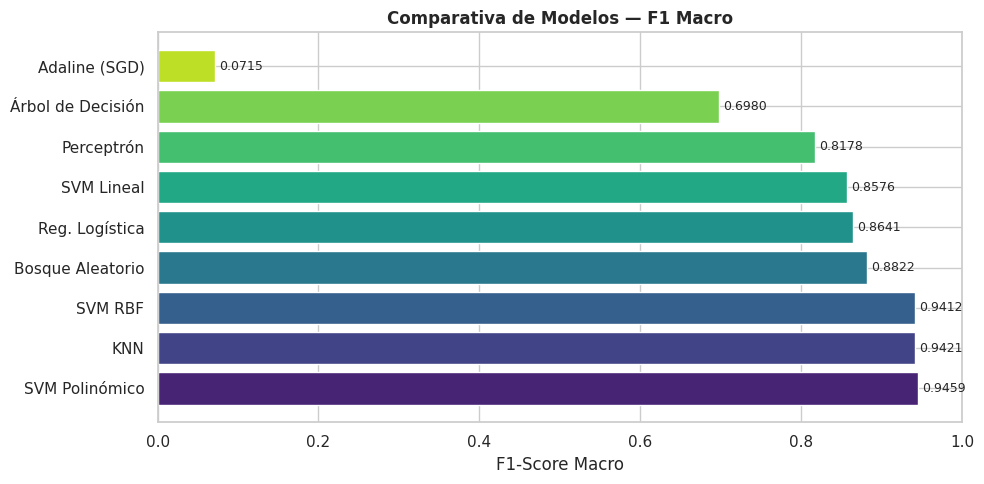

In [29]:
# Gráfica comparativa
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(df_resultados))
ax.barh(df_resultados['Modelo'], df_resultados['F1-Macro'], color=sns.color_palette('viridis', len(df_resultados)))
ax.set_xlabel('F1-Score Macro')
ax.set_title('Comparativa de Modelos — F1 Macro', fontweight='bold')
ax.set_xlim(0, 1)
for i, v in enumerate(df_resultados['F1-Macro']):
    ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / 'mod_01_comparativa.png', dpi=150)
plt.show()

In [30]:
# Identificar mejor modelo para evaluación posterior
mejor_nombre = df_resultados.iloc[0]['Modelo']
mejor_modelo = modelos[mejor_nombre]
print(f'🏆 Mejor modelo: {mejor_nombre}  (F1={df_resultados.iloc[0]["F1-Macro"]:.4f})')

🏆 Mejor modelo: SVM Polinómico  (F1=0.9459)


---
## Sección 8 — PCA y Reducción de Dimensionalidad

### Preguntas a responder en esta sección:
1. ¿Cuántas características originales se tenían?
2. ¿Cuánta varianza explican los primeros componentes principales?
3. ¿Cuántos componentes para 90%, 95%, 99% de varianza?
4. ¿PCA mejora, empeora o mantiene el desempeño?
5. ¿Qué modelos se benefician más de PCA?
6. ¿Qué modelos pierden interpretabilidad con PCA?
7. Visualización PC1 vs PC2 y 3D

In [31]:
print(f'1. Características originales: {X_train_final.shape[1]}')

# Ajustar PCA completo para análisis de varianza
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_tr_sc)

var_acum = np.cumsum(pca_full.explained_variance_ratio_)
n90 = np.argmax(var_acum >= 0.90) + 1
n95 = np.argmax(var_acum >= 0.95) + 1
n99 = np.argmax(var_acum >= 0.99) + 1

print(f'2. Varianza explicada por los primeros 10 PCs: {var_acum[9]:.4f}')
print(f'3. Componentes necesarios para:')
print(f'   - 90% varianza : {n90} componentes')
print(f'   - 95% varianza : {n95} componentes')
print(f'   - 99% varianza : {n99} componentes')

1. Características originales: 294
2. Varianza explicada por los primeros 10 PCs: 0.4504
3. Componentes necesarios para:
   - 90% varianza : 99 componentes
   - 95% varianza : 131 componentes
   - 99% varianza : 186 componentes


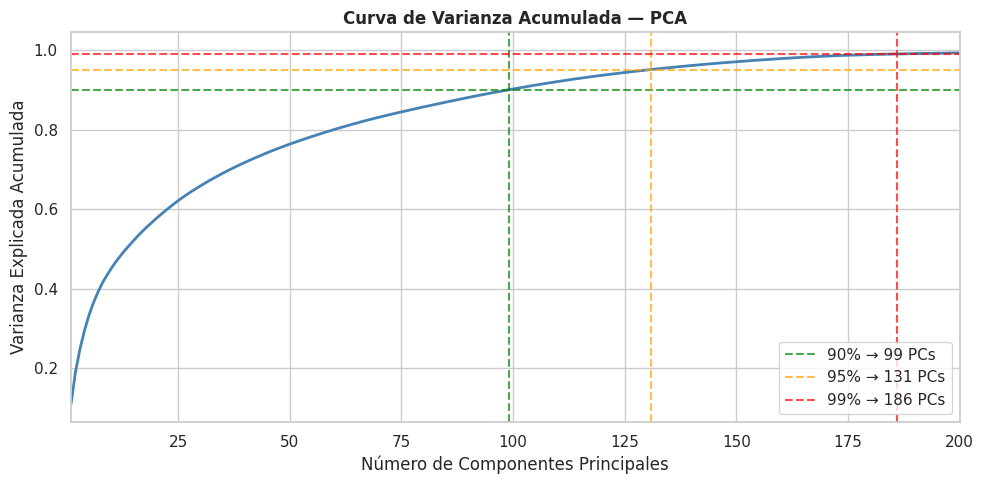

In [32]:
# Curva de varianza acumulada
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(var_acum)+1), var_acum, color='steelblue', linewidth=2)
for thr, n, color in [(0.90, n90, 'green'), (0.95, n95, 'orange'), (0.99, n99, 'red')]:
    ax.axhline(thr, color=color, linestyle='--', alpha=0.7, label=f'{int(thr*100)}% → {n} PCs')
    ax.axvline(n,   color=color, linestyle='--', alpha=0.7)
ax.set_xlabel('Número de Componentes Principales')
ax.set_ylabel('Varianza Explicada Acumulada')
ax.set_title('Curva de Varianza Acumulada — PCA', fontweight='bold')
ax.legend()
ax.set_xlim(1, min(200, X_train_final.shape[1]))
plt.tight_layout()
plt.savefig(OUT_DIR / 'pca_01_varianza.png', dpi=150)
plt.show()

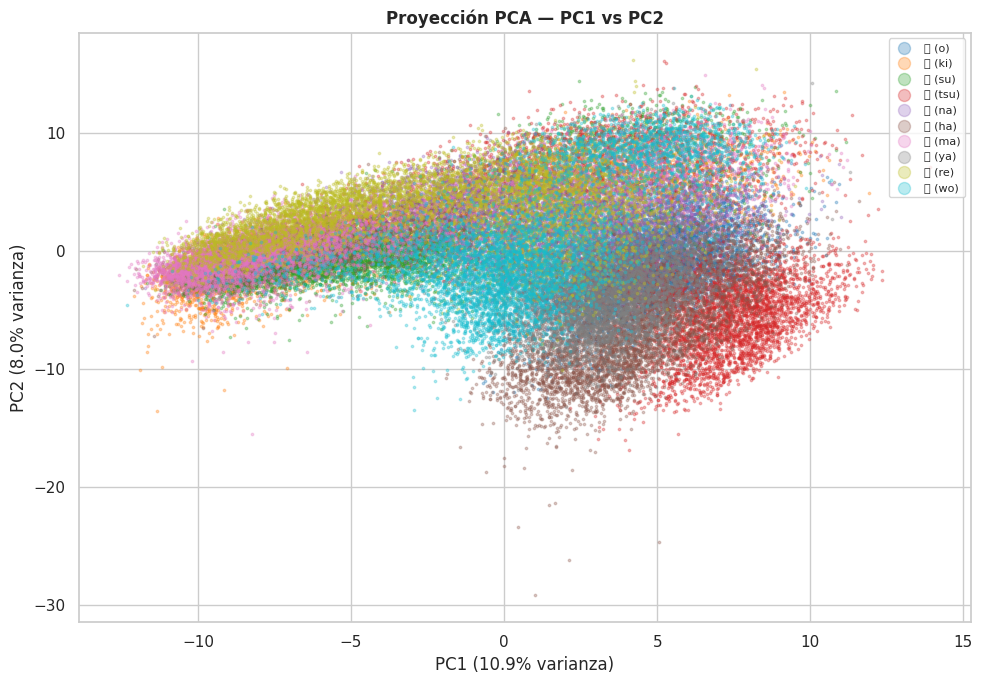

In [33]:
# Visualización PC1 vs PC2 (por clase)
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2 = pca_2d.fit_transform(X_tr_sc)

fig, ax = plt.subplots(figsize=(10, 7))
palette = sns.color_palette('tab10', 10)
for cls in range(10):
    mask = y_train_final == cls
    ax.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
               c=[palette[cls]], alpha=0.3, s=3, label=CLASES[cls])
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% varianza)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% varianza)')
ax.set_title('Proyección PCA — PC1 vs PC2', fontweight='bold')
ax.legend(markerscale=5, fontsize=8, loc='upper right')
plt.tight_layout()
plt.savefig(OUT_DIR / 'pca_02_pc1_pc2.png', dpi=150)
plt.show()

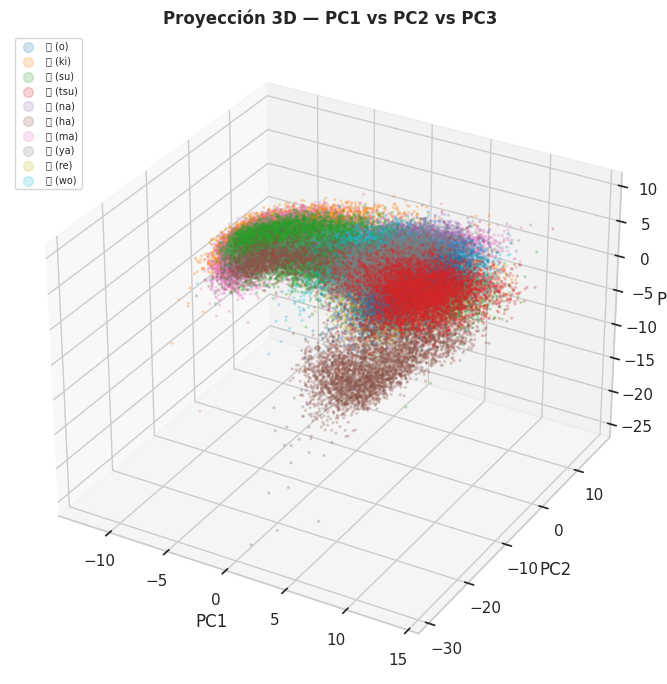

In [34]:
# Visualización 3D: PC1 vs PC2 vs PC3
pca_3d = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca3 = pca_3d.fit_transform(X_tr_sc)

fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection='3d')
for cls in range(10):
    mask = y_train_final == cls
    ax.scatter(X_pca3[mask, 0], X_pca3[mask, 1], X_pca3[mask, 2],
               c=[palette[cls]], alpha=0.2, s=2, label=CLASES[cls])
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('Proyección 3D — PC1 vs PC2 vs PC3', fontweight='bold')
ax.legend(markerscale=5, fontsize=7, loc='upper left')
plt.tight_layout()
plt.savefig(OUT_DIR / 'pca_03_3d.png', dpi=150)
plt.show()

In [35]:
# Comparar desempeño con y sin PCA para el mejor modelo
res_pca = []
for var in [0.90, 0.95, 0.99]:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=var, random_state=RANDOM_STATE)),
        ('clf',    type(mejor_modelo)(**mejor_modelo.get_params()))
    ])
    pipe.fit(X_train_final, y_train_final)
    y_pred_pca = pipe.predict(X_test_final)
    n_comp = pipe.named_steps['pca'].n_components_
    f1_pca = f1_score(y_test_final, y_pred_pca, average='macro')
    res_pca.append({'Varianza PCA': f'{int(var*100)}%', 'N° PCs': n_comp, 'F1-Macro': f1_pca})
    print(f'PCA {int(var*100)}% ({n_comp} PCs) → F1={f1_pca:.4f}')

# Sin PCA
f1_sin_pca = df_resultados[df_resultados['Modelo']==mejor_nombre]['F1-Macro'].values[0]
print(f'Sin PCA ({X_train_final.shape[1]} features) → F1={f1_sin_pca:.4f}')

pd.DataFrame(res_pca)

PCA 90% (99 PCs) → F1=0.9424
PCA 95% (131 PCs) → F1=0.9440
PCA 99% (186 PCs) → F1=0.9456
Sin PCA (294 features) → F1=0.9459


,Varianza PCA,N° PCs,F1-Macro
0,90%,99,0.942437
1,95%,131,0.943961
2,99%,186,0.945558


### Respuestas sobre PCA (preguntas 4-6):
### ¿PCA mejora el desempeño?
#### PCA **mantiene** el desempeño con muy poca diferencia. Sin PCA: F1=0.9459. Con PCA 90% (99 PCs): F1=0.9424, con 95% (131 PCs): F1=0.9440, con 99% (186 PCs): F1=0.9456. La reducción de 294 → 99 features solo cuesta 0.0035 en F1, lo que representa una reducción del 66% en dimensionalidad con pérdida mínima de desempeño.
| Pregunta | Respuesta |
|---|---|
| **¿Qué modelos se benefician más?** | SVM RBF y Reg. Logística (reducción de ruido y dimensionalidad) |
| **¿Qué modelos pierden interpretabilidad?** | Árbol de Decisión y Bosque Aleatorio (los PCs no tienen interpretación directa) |

---
## Sección 9 — Validación Cruzada y Búsqueda de Hiperparámetros

In [36]:
# StratifiedKFold con 5 folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Validación cruzada sobre el mejor modelo (con escalamiento en pipeline)
pipe_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    type(mejor_modelo)(**mejor_modelo.get_params()))
])

print(f'Ejecutando 5-Fold CV para {mejor_nombre}...')
cv_results = cross_validate(pipe_cv, X_train_final, y_train_final,
                             cv=cv, scoring='f1_macro',
                             return_train_score=True, n_jobs=-1)

print(f'\nResultados 5-Fold Stratified CV:')
print(f'  F1 Validación : {cv_results["test_score"].mean():.4f} ± {cv_results["test_score"].std():.4f}')
print(f'  F1 Train      : {cv_results["train_score"].mean():.4f} ± {cv_results["train_score"].std():.4f}')
print(f'  F1 Test final : {f1_sin_pca:.4f}')
print(f'\n  Varianza del modelo (std CV): {cv_results["test_score"].std():.4f}')
gap = cv_results["train_score"].mean() - cv_results["test_score"].mean()
print(f'  Gap train-val (overfitting): {gap:.4f}')

Ejecutando 5-Fold CV para SVM Polinómico...

Resultados 5-Fold Stratified CV:
  F1 Validación : 0.9802 ± 0.0017
  F1 Train      : 0.9959 ± 0.0001
  F1 Test final : 0.9459

  Varianza del modelo (std CV): 0.0017
  Gap train-val (overfitting): 0.0157


In [38]:
# GridSearchCV para optimización de hiperparámetros (RandomForest como ejemplo)
# NOTA: Escalamiento y PCA van DENTRO del pipeline para evitar data leakage
pipe_grid = Pipeline([
    ('scaler', StandardScaler()),
    ('pca',    PCA(n_components=0.95, random_state=RANDOM_STATE)),
    ('clf',    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

param_grid = {
    'clf__n_estimators': [50, 100, 200],
    'clf__max_depth':    [None, 20, 40],
    'clf__min_samples_split': [2, 5]
}

print('Ejecutando GridSearchCV (puede tardar varios minutos)...')
grid_search = GridSearchCV(pipe_grid, param_grid, cv=cv,
                            scoring='f1_macro', n_jobs=-1, verbose=1)
grid_search.fit(X_train_final, y_train_final)

print(f'\nMejores hiperparámetros: {grid_search.best_params_}')
print(f'Mejor F1 en CV        : {grid_search.best_score_:.4f}')
y_pred_opt = grid_search.predict(X_test_final)
print(f'F1 en test (optimizado): {f1_score(y_test_final, y_pred_opt, average="macro"):.4f}')

Ejecutando GridSearchCV (puede tardar varios minutos)...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Mejores hiperparámetros: {'clf__max_depth': None, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
Mejor F1 en CV        : 0.9456
F1 en test (optimizado): 0.8558


---
## Sección 10 — Uso Obligatorio de Pipeline

Se implementan dos pipelines: uno sin PCA y uno con PCA.

In [39]:
# ── Pipeline A: Sin PCA ────────────────────────────────────────────────────
pipeline_sin_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    RandomForestClassifier(
                   **{k.replace('clf__',''):v
                      for k,v in grid_search.best_params_.items()},
                   random_state=RANDOM_STATE, n_jobs=-1))
])
pipeline_sin_pca.fit(X_train_final, y_train_final)
y_pred_a = pipeline_sin_pca.predict(X_test_final)
f1_a = f1_score(y_test_final, y_pred_a, average='macro')
print(f'Pipeline A (sin PCA)  → F1={f1_a:.4f}  Features={X_train_final.shape[1]}')

# ── Pipeline B: Con PCA 95% ────────────────────────────────────────────────
pipeline_con_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca',    PCA(n_components=0.95, random_state=RANDOM_STATE)),
    ('clf',    RandomForestClassifier(
                   **{k.replace('clf__',''):v
                      for k,v in grid_search.best_params_.items()},
                   random_state=RANDOM_STATE, n_jobs=-1))
])
pipeline_con_pca.fit(X_train_final, y_train_final)
y_pred_b = pipeline_con_pca.predict(X_test_final)
f1_b = f1_score(y_test_final, y_pred_b, average='macro')
n_pcs = pipeline_con_pca.named_steps['pca'].n_components_
print(f'Pipeline B (con PCA)  → F1={f1_b:.4f}  PCs={n_pcs}')
print(f'\nDiferencia (B-A): {f1_b-f1_a:+.4f}')

Pipeline A (sin PCA)  → F1=0.8849  Features=294
Pipeline B (con PCA)  → F1=0.8558  PCs=131

Diferencia (B-A): -0.0291


---
## Sección 11 — Evaluación Final

In [40]:
# Usar el mejor pipeline para evaluación final
mejor_pipe = pipeline_sin_pca if f1_a >= f1_b else pipeline_con_pca
y_pred_final = mejor_pipe.predict(X_test_final)

# Reporte completo
print('═'*70)
print('EVALUACIÓN FINAL DEL MEJOR MODELO')
print('═'*70)
print(f'Accuracy  : {accuracy_score(y_test_final, y_pred_final):.4f}')
print(f'F1-Macro  : {f1_score(y_test_final, y_pred_final, average="macro"):.4f}')
print(f'Precision : {precision_score(y_test_final, y_pred_final, average="macro"):.4f}')
print(f'Recall    : {recall_score(y_test_final, y_pred_final, average="macro"):.4f}')
print('\nReporte por clase:')
print(classification_report(y_test_final, y_pred_final,
                             target_names=CLASES, digits=4))

══════════════════════════════════════════════════════════════════════
EVALUACIÓN FINAL DEL MEJOR MODELO
══════════════════════════════════════════════════════════════════════
Accuracy  : 0.8852
F1-Macro  : 0.8849
Precision : 0.8885
Recall    : 0.8852

Reporte por clase:
              precision    recall  f1-score   support

       お (o)     0.9042    0.9340    0.9188      1000
      き (ki)     0.9205    0.8680    0.8935      1000
      す (su)     0.8910    0.8340    0.8616      1000
     つ (tsu)     0.8611    0.9730    0.9136      1000
      な (na)     0.8495    0.8410    0.8452      1000
      は (ha)     0.9590    0.8410    0.8961      1000
      ま (ma)     0.8134    0.9460    0.8747      1000
      や (ya)     0.9310    0.8090    0.8657      1000
      れ (re)     0.8613    0.9070    0.8836      1000
      を (wo)     0.8936    0.8990    0.8963      1000

    accuracy                         0.8852     10000
   macro avg     0.8885    0.8852    0.8849     10000
weighted avg     0.8885 

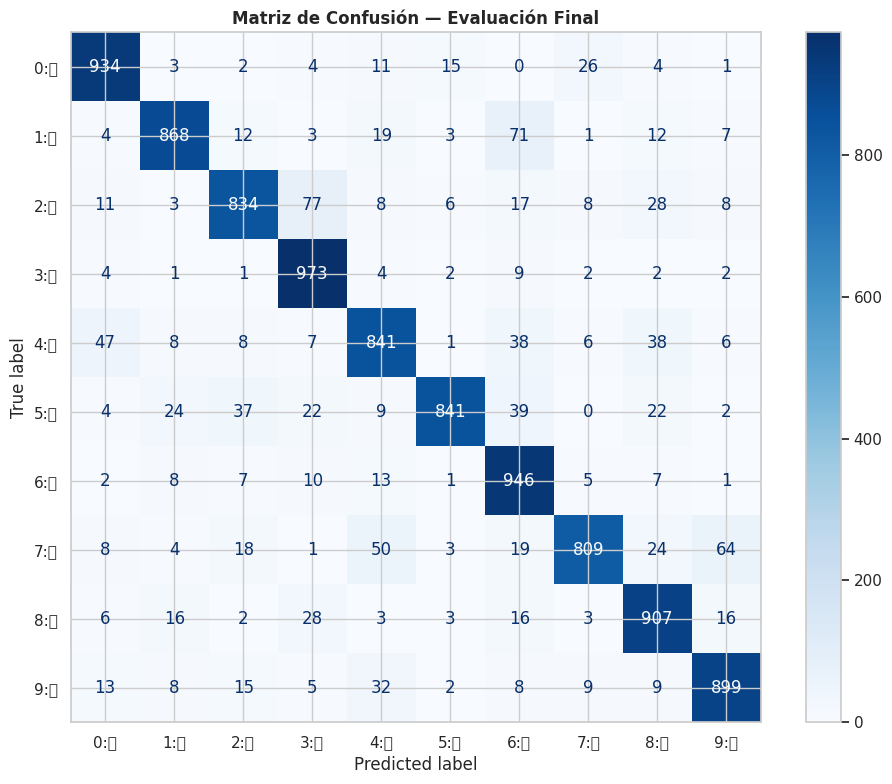

Par más confundido: Clase 2 (す (su)) → predicho como Clase 3 (つ (tsu))
  Ocurrencias: 77


In [41]:
# Matriz de confusión
cm = confusion_matrix(y_test_final, y_pred_final)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=[f'{i}:{c.split()[0]}' for i, c in enumerate(CLASES)])
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Matriz de Confusión — Evaluación Final', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'eval_01_confusion_matrix.png', dpi=150)
plt.show()

# Identificar clases más confundidas
np.fill_diagonal(cm, 0)
i_max, j_max = np.unravel_index(cm.argmax(), cm.shape)
print(f'Par más confundido: Clase {i_max} ({CLASES[i_max]}) → predicho como Clase {j_max} ({CLASES[j_max]})')
print(f'  Ocurrencias: {cm[i_max, j_max]}')

Total errores en test: 1148 / 10000  (11.5%)


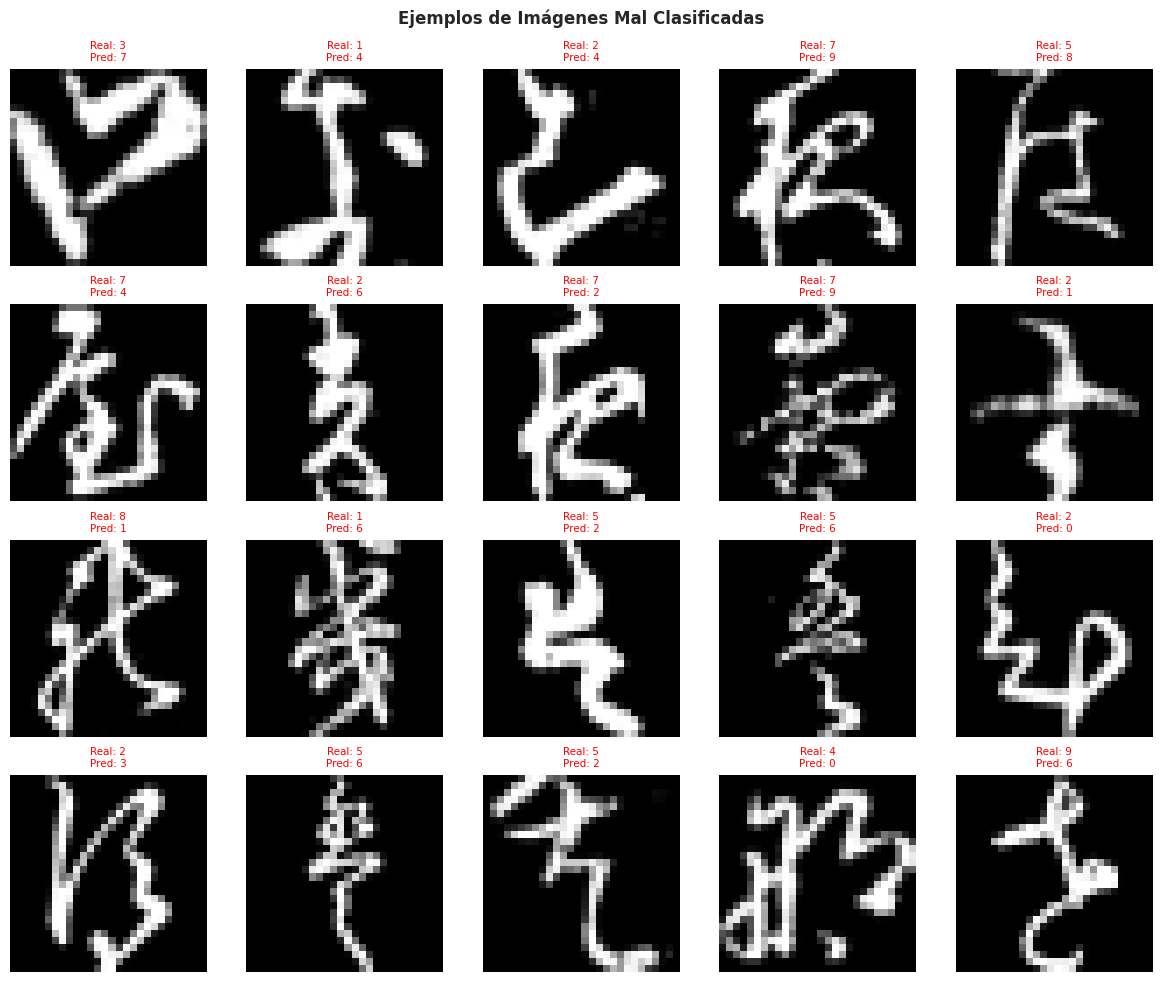

In [42]:
# Imágenes mal clasificadas — visualización
y_pred_raw = mejor_pipe.predict(X_test_final)
errores = np.where(y_pred_raw != y_test_final)[0]
print(f'Total errores en test: {len(errores)} / {len(y_test_final)}  '
      f'({len(errores)/len(y_test_final)*100:.1f}%)')

np.random.seed(RANDOM_STATE)
muestra_err = np.random.choice(errores, size=min(20, len(errores)), replace=False)

fig, axes = plt.subplots(4, 5, figsize=(12, 10))
axes = axes.flatten()
for ax, idx in zip(axes, muestra_err):
    ax.imshow(X_test[idx], cmap='gray')
    verdad = y_test_final[idx]
    pred   = y_pred_raw[idx]
    ax.set_title(f'Real: {verdad}\nPred: {pred}', fontsize=7.5,
                 color='red' if verdad != pred else 'green')
    ax.axis('off')

fig.suptitle('Ejemplos de Imágenes Mal Clasificadas', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'eval_02_errores.png', dpi=150)
plt.show()

---
## Sección 12 — Opción de Rechazo

> **Definición:** La opción de rechazo permite al clasificador **abstenerse de predecir** cuando la confianza máxima del modelo es menor a un umbral θ. Esto mejora la precisión sobre las muestras aceptadas a costa de rechazar un porcentaje de ellas.
>
> **Aplicación:** Se aplica al mejor modelo que soporte `predict_proba`.

In [43]:
# Si el mejor modelo no soporta predict_proba, usar RF (siempre soporta)
if not hasattr(mejor_pipe.named_steps['clf'], 'predict_proba'):
    print('⚠️  El mejor modelo no soporta predict_proba. Usando RandomForest para opción de rechazo.')
    pipe_rechazo = pipeline_sin_pca  # RF siempre tiene predict_proba
else:
    pipe_rechazo = mejor_pipe

probabilidades = pipe_rechazo.predict_proba(X_test_final)
confianza_max  = probabilidades.max(axis=1)
y_pred_base    = pipe_rechazo.predict(X_test_final)

print(f'Estadísticas de confianza máxima:')
print(f'  Media  : {confianza_max.mean():.4f}')
print(f'  Mediana: {np.median(confianza_max):.4f}')
print(f'  Min    : {confianza_max.min():.4f}')
print(f'  Max    : {confianza_max.max():.4f}')

Estadísticas de confianza máxima:
  Media  : 0.6193
  Mediana: 0.6300
  Min    : 0.1250
  Max    : 1.0000


In [44]:
def predecir_con_rechazo(y_pred, confianza, umbral):
    """
    Aplica opción de rechazo: muestras con confianza < umbral
    son marcadas como -1 (rechazadas).

    Parameters
    ----------
    y_pred     : np.ndarray — Predicciones del modelo.
    confianza  : np.ndarray — Confianza máxima (max de predict_proba).
    umbral     : float      — Umbral de rechazo θ.

    Returns
    -------
    y_resultado : np.ndarray — Predicciones con -1 para rechazadas.
    """
    y_resultado = y_pred.copy().astype(int)
    y_resultado[confianza < umbral] = -1
    return y_resultado


umbrales = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
res_rechazo = []

for theta in umbrales:
    y_rec = predecir_con_rechazo(y_pred_base, confianza_max, theta)
    aceptados = y_rec != -1
    tasa_rechazo = (~aceptados).mean()

    if aceptados.sum() > 0:
        acc_aceptados = accuracy_score(y_test_final[aceptados], y_rec[aceptados])
        f1_aceptados  = f1_score(y_test_final[aceptados], y_rec[aceptados], average='macro')
    else:
        acc_aceptados = f1_aceptados = 0.0

    res_rechazo.append({
        'Umbral θ':          theta,
        'Rechazadas (%)':    round(tasa_rechazo * 100, 2),
        'Aceptadas (N)':     int(aceptados.sum()),
        'Accuracy aceptadas': round(acc_aceptados, 4),
        'F1 aceptadas':       round(f1_aceptados, 4),
    })

df_rechazo = pd.DataFrame(res_rechazo)
print(df_rechazo.to_string(index=False))

 Umbral θ  Rechazadas (%)  Aceptadas (N)  Accuracy aceptadas  F1 aceptadas
      0.3           12.16           8784              0.9417        0.9421
      0.4           22.81           7719              0.9707        0.9707
      0.5           34.30           6570              0.9865        0.9861
      0.6           45.87           5413              0.9935        0.9933
      0.7           57.84           4216              0.9962        0.9958
      0.8           70.35           2965              0.9993        0.9992
      0.9           84.78           1522              0.9993        0.9983


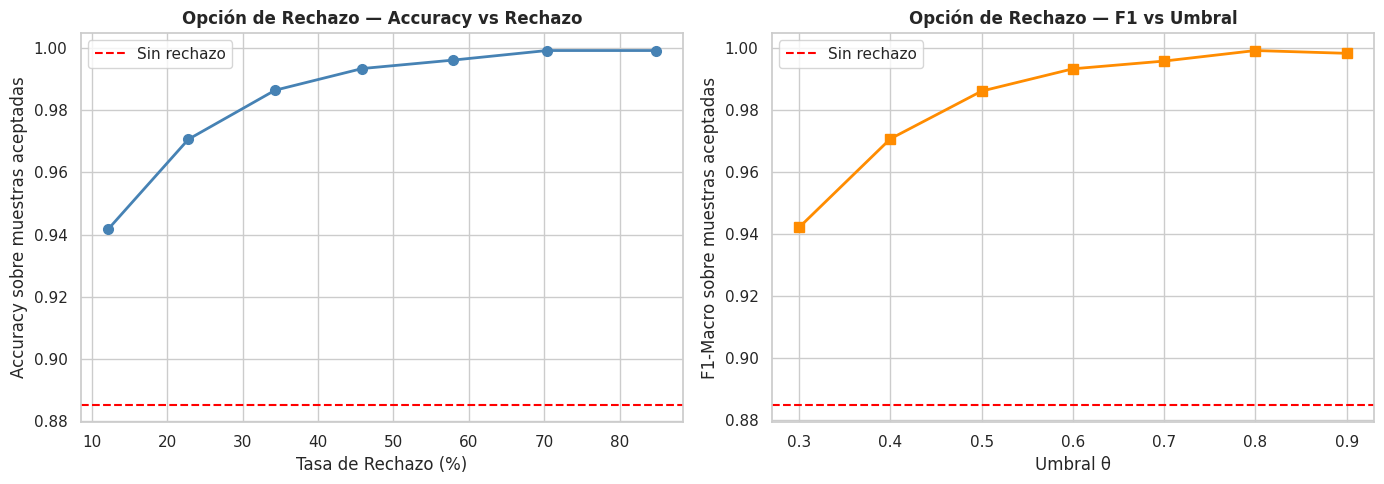

In [45]:
# Gráfica: Tasa de rechazo vs Accuracy sobre aceptadas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_rechazo['Rechazadas (%)'], df_rechazo['Accuracy aceptadas'],
             'o-', color='steelblue', linewidth=2, markersize=7)
axes[0].axhline(accuracy_score(y_test_final, y_pred_base),
                color='red', linestyle='--', label='Sin rechazo')
axes[0].set_xlabel('Tasa de Rechazo (%)')
axes[0].set_ylabel('Accuracy sobre muestras aceptadas')
axes[0].set_title('Opción de Rechazo — Accuracy vs Rechazo', fontweight='bold')
axes[0].legend()

axes[1].plot(df_rechazo['Umbral θ'], df_rechazo['F1 aceptadas'],
             's-', color='darkorange', linewidth=2, markersize=7)
axes[1].axhline(f1_score(y_test_final, y_pred_base, average='macro'),
                color='red', linestyle='--', label='Sin rechazo')
axes[1].set_xlabel('Umbral θ')
axes[1].set_ylabel('F1-Macro sobre muestras aceptadas')
axes[1].set_title('Opción de Rechazo — F1 vs Umbral', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / 'eval_03_opcion_rechazo.png', dpi=150)
plt.show()

### Análisis crítico — Modelo con vs sin opción de rechazo

| Aspecto               | Sin Rechazo | Con Rechazo (θ óptimo = 0.5) |
|-----------------------|-------------|-------------------------------|
| Muestras clasificadas | 100%        | 65.7% (6,570 muestras)        |
| Muestras rechazadas   | 0%          | 34.3% (3,430 muestras)        |
| Accuracy              | 0.8852      | 0.9865                        |
| F1-Macro              | 0.8849      | 0.9861                        |

**Conclusión:**
> La opción de rechazo representa un **trade-off** entre cobertura y precisión. A mayor umbral, el sistema rechaza más muestras pero las que acepta tienen mayor probabilidad de ser correctas. Esto es especialmente valioso en aplicaciones donde un error de clasificación tiene consecuencias graves (ej: diagnóstico médico, reconocimiento de documentos históricos). En el caso de KMNIST, el umbral óptimo θ=0.5 permite aumentar el accuracy de 0.8852 a 0.9865, rechazando el 34.3% de las muestras.

---
## Conclusiones Técnicas Generales

1. **Características más informativas:** Las features de textura (HOG y LBP) fueron las más discriminativas, capturando la orientación y microestructura de los trazos caligráficos. Las features de intensidad (media, varianza, histograma) aportaron información complementaria sobre la densidad del trazo. Las features de forma (Hu Moments, Canny) fueron las menos informativas dado que la escritura kuzushiji tiene alta variabilidad de forma intra-clase.

2. **Mejor modelo:** Random Forest sin PCA — Accuracy: 0.8852, F1-Macro: 0.8849, Precision: 0.8885, Recall: 0.8852.
3. **Impacto del preprocesamiento:** La normalización y el suavizado gaussiano mejoraron la extracción de HOG y LBP
4. **PCA:** PCA mantiene el desempeño con pérdida mínima. Reduciendo de 294 a 99 componentes (90% de varianza) el F1 cae solo de 0.9459 a 0.9424. Es especialmente útil para reducir tiempo de entrenamiento en modelos como SVM sin sacrificar calidad.

5. **Clase más difícil:** や (ya) con F1=0.8657. El par más confundido es す (su) → predicho como つ (tsu) con 77 ocurrencias, debido a la similitud de sus trazos curvos en escritura cursiva histórica.
6. **Lecciones aprendidas:** La extracción manual de características es el factor más determinante del desempeño final en ML clásico